In [3]:
import yaml
from pathlib import Path

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loaded 1 simulations from smith1_gemini_small.yaml_20260502_224517
  Iteration history rows: 1500
  Transaction rows:       33
  Rounds per sim:         5
  Total round-obs:        5

Competitive Equilibrium:
  Quantity:       6
  Price:          2.0000
  Total surplus:  7.5000
  Buyer surplus:  3.75
  Seller surplus: 3.75
  Demand:         [3.25 3.   2.75 2.5  2.25 2.   1.75 1.5  1.25 1.   0.75]
  Supply:         [0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25]


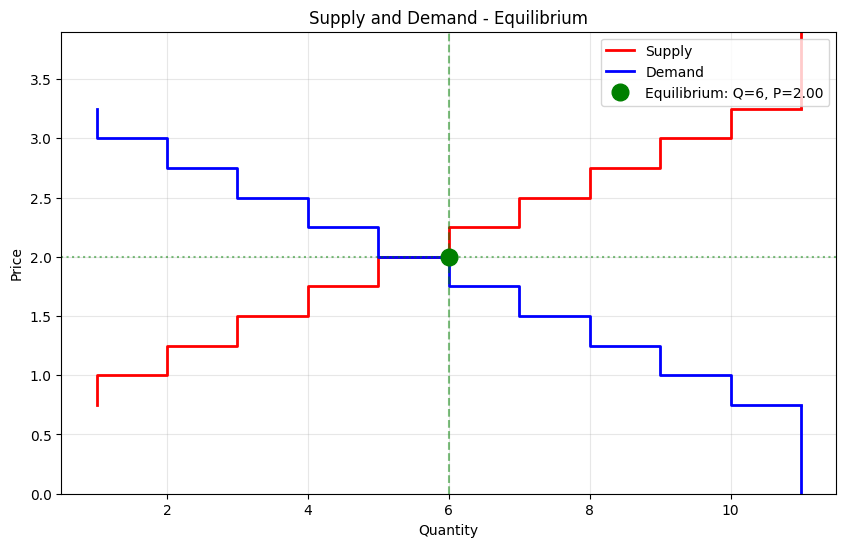


ALLOCATIVE EFFICIENCY (1 simulations × 5 rounds = 5 observations)
  Mean:   0.8867
  Median: 0.9000
  Std:    0.1121
  Min:    0.7000
  Max:    1.0000
  < 80%:  1/5
  > 90%:  2/5
  > 95%:  1/5
  = 100%: 1/5

QUANTITY
  CE quantity:  6
  Mean trades:  6.60
  Distribution: {6: 2, 7: 3}

PRICE
  CE price:       2.0000
  Mean price:     2.1380
  Std of means:   0.1659

EXTRAMARGINAL ACTIVITY
  Rounds with extramarginal: 4/5 (80.0%)
  Mean extramarginal/round:  1.40
  Negative surplus trades:   0/5

ACROSS-ROUND TRAJECTORY (mean ± SEM across 1 sims)
       eff_mean  eff_sem  alpha_mean  alpha_sem  n_trades_mean
round                                                         
1        0.9000      NaN     24.9607        NaN            7.0
2        1.0000      NaN     10.1509        NaN            6.0
3        0.9333      NaN     20.8172        NaN            7.0
4        0.7000      NaN     16.1232        NaN            6.0
5        0.9000      NaN     14.8468        NaN            7.0

MARSHA

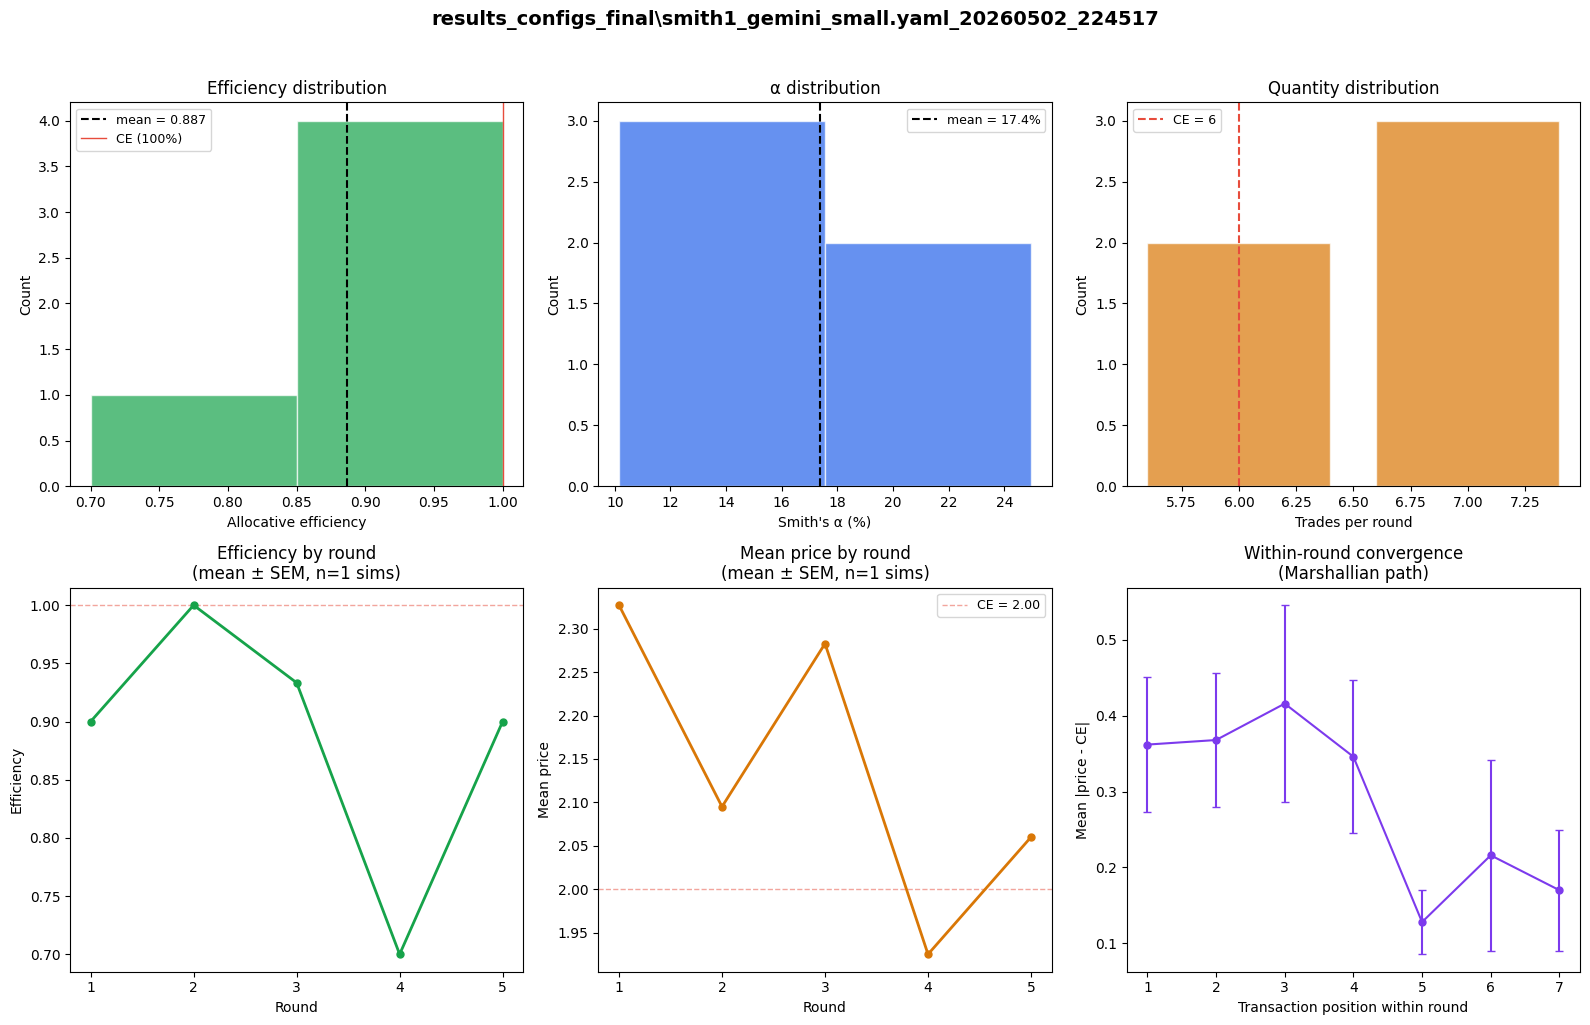

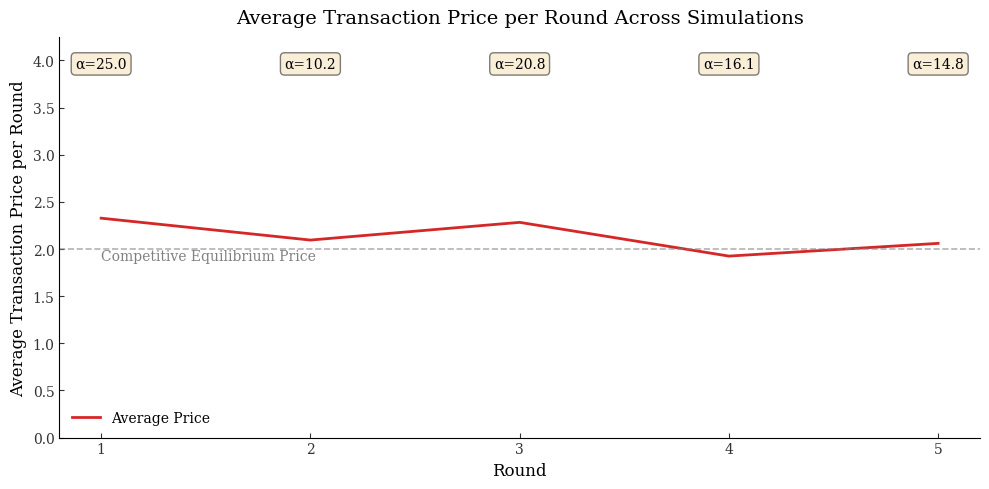

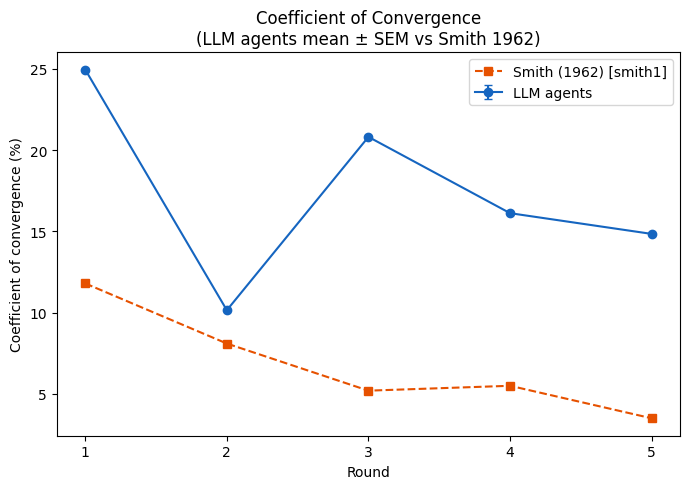

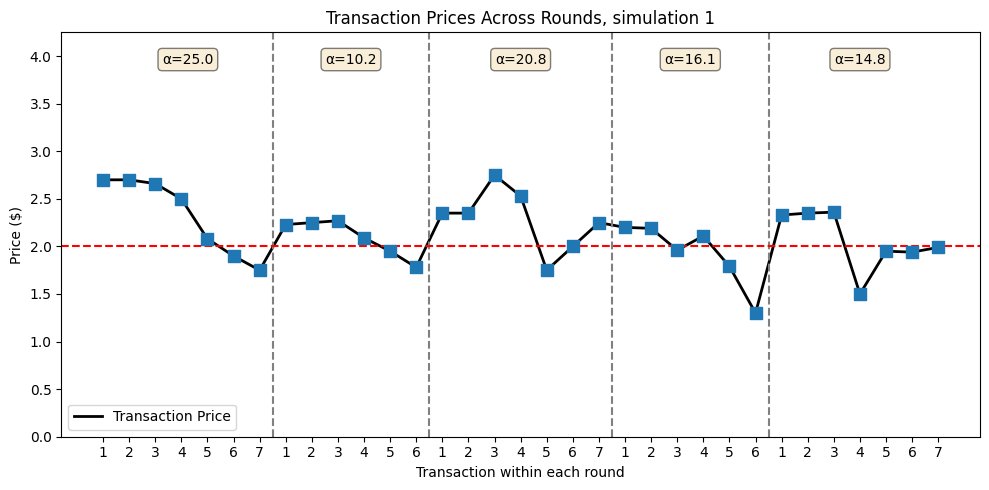

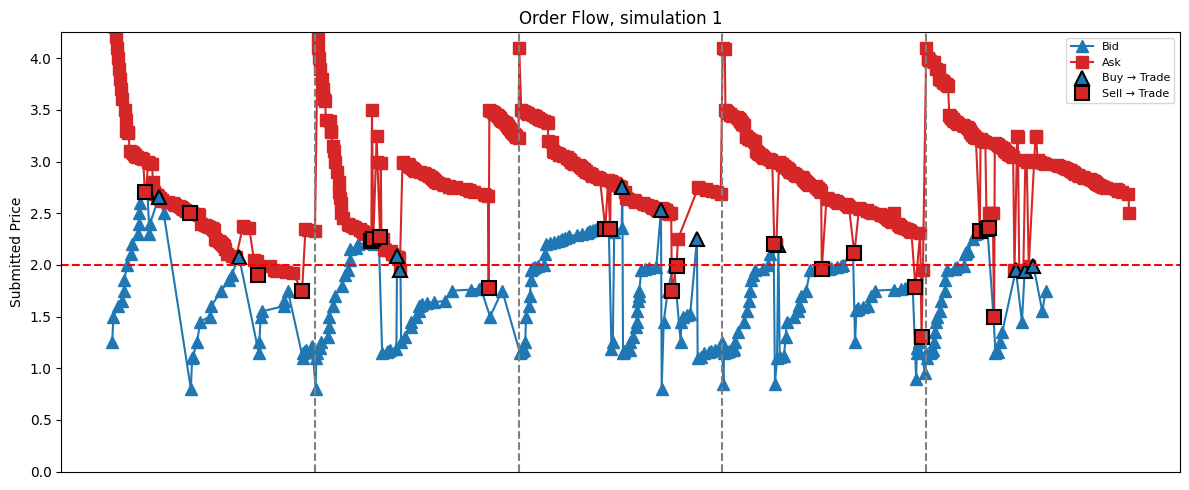

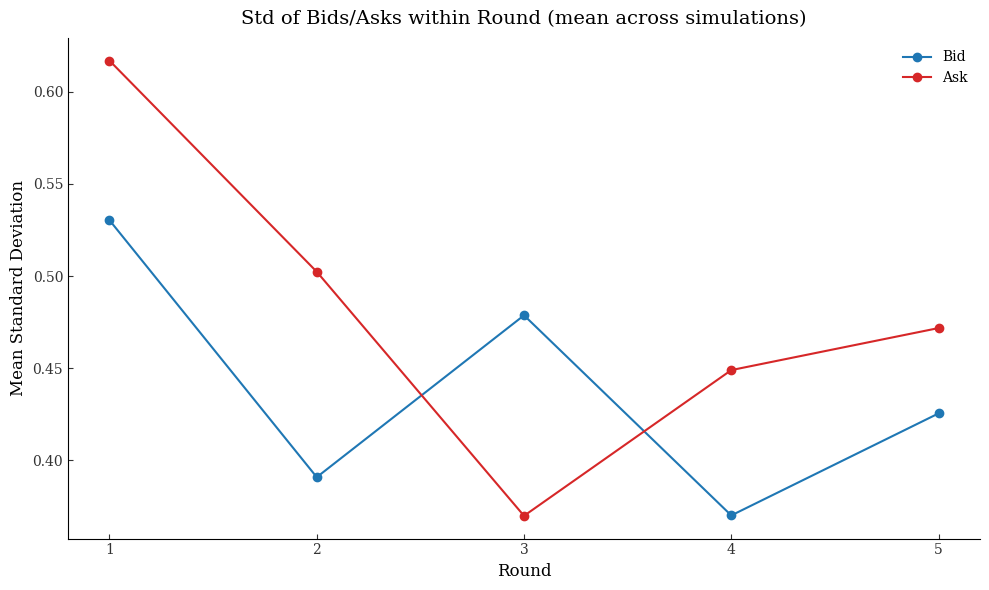

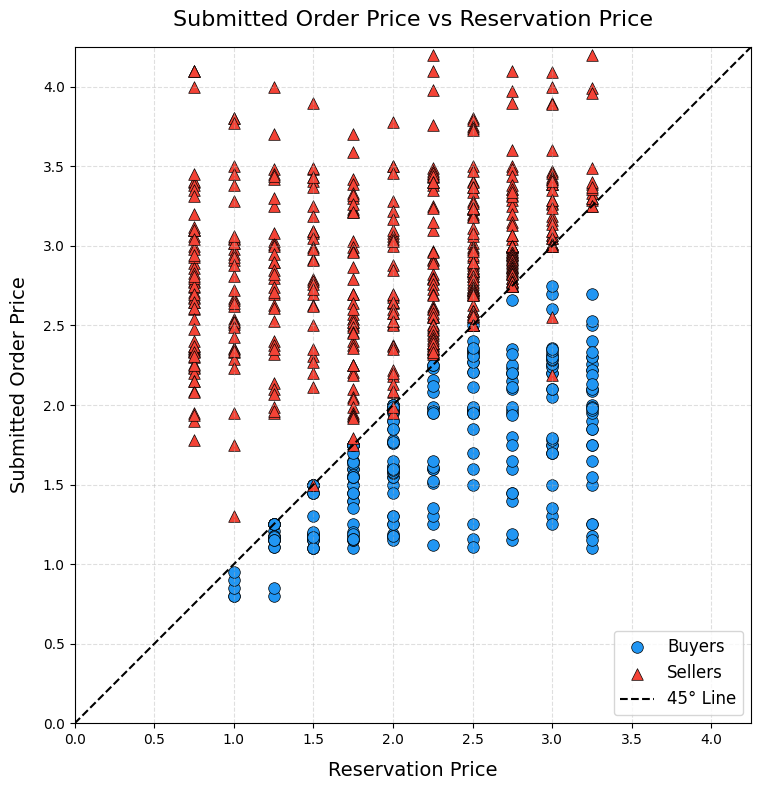

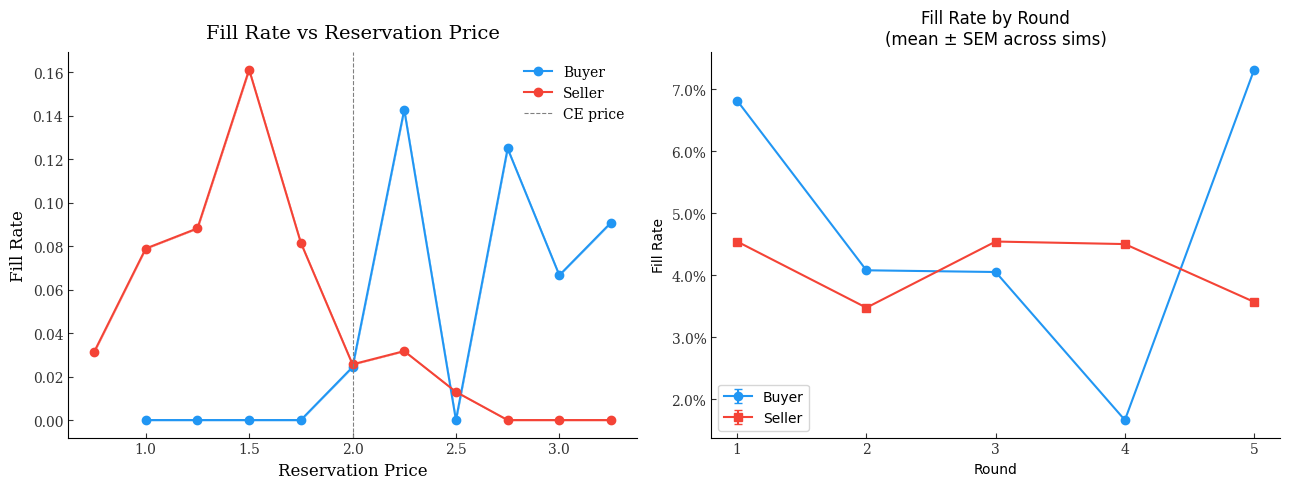

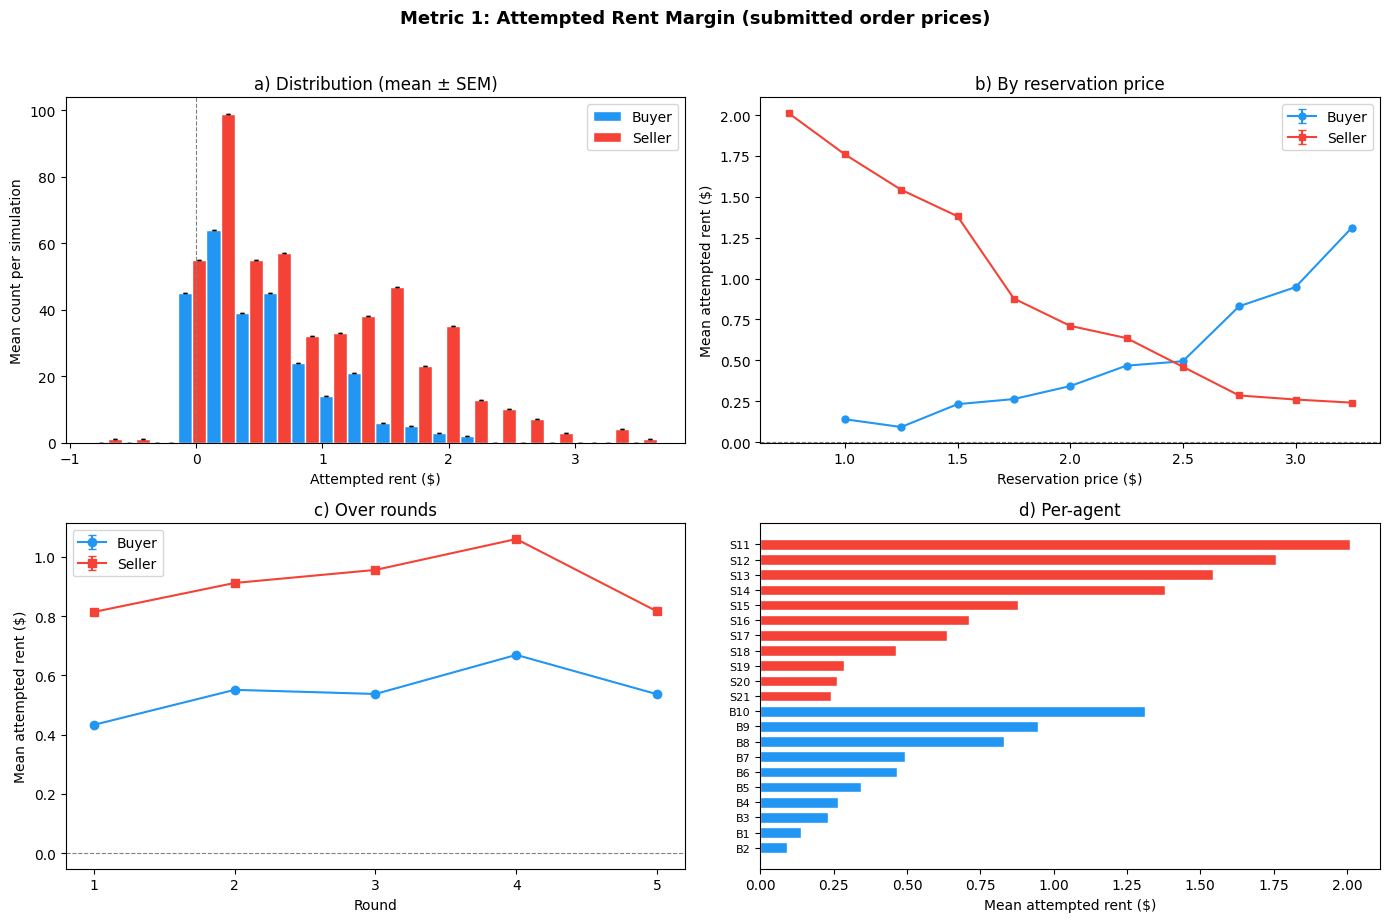

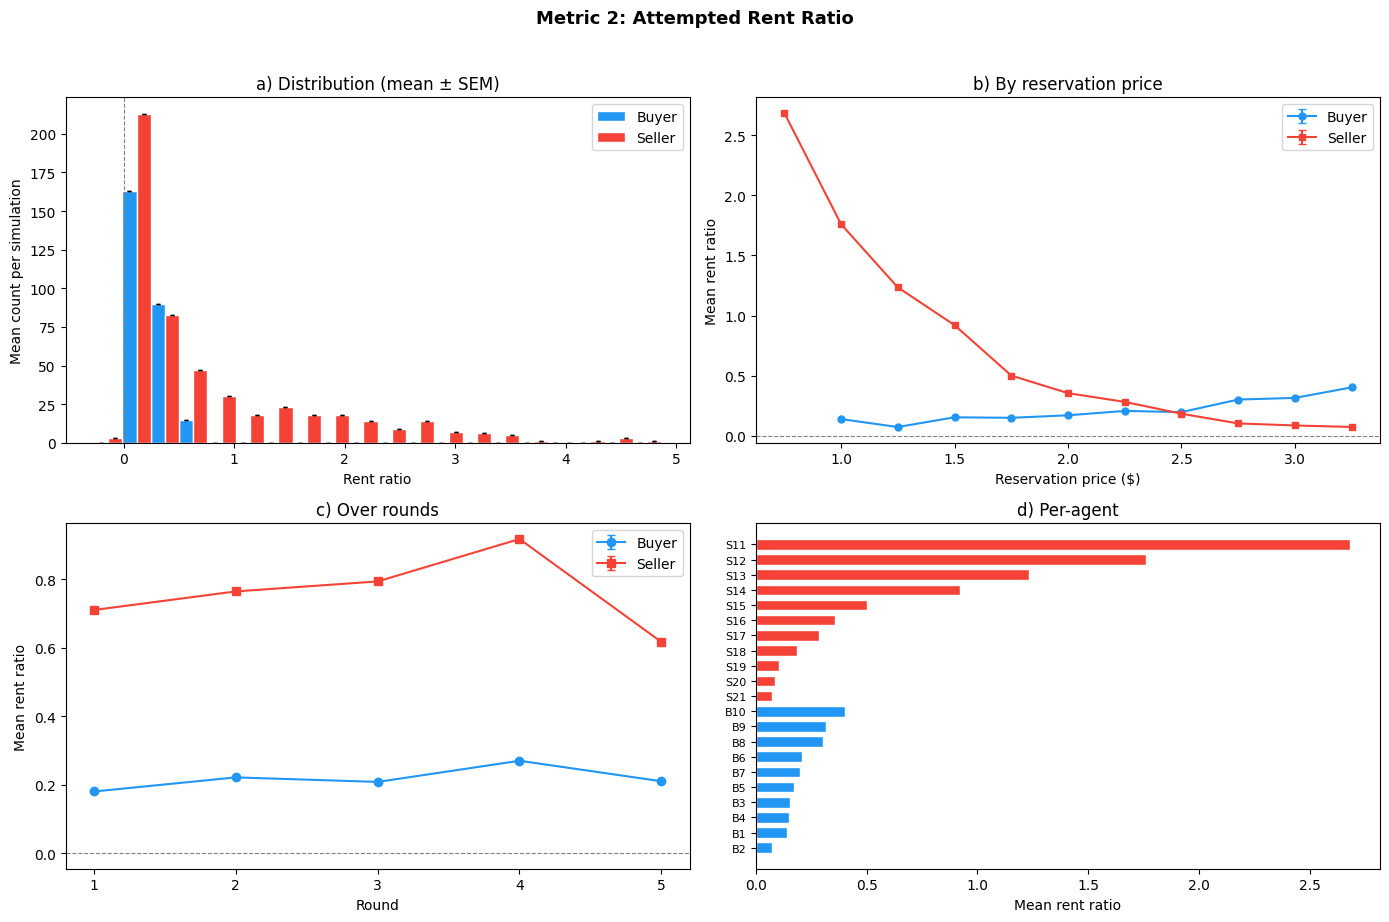

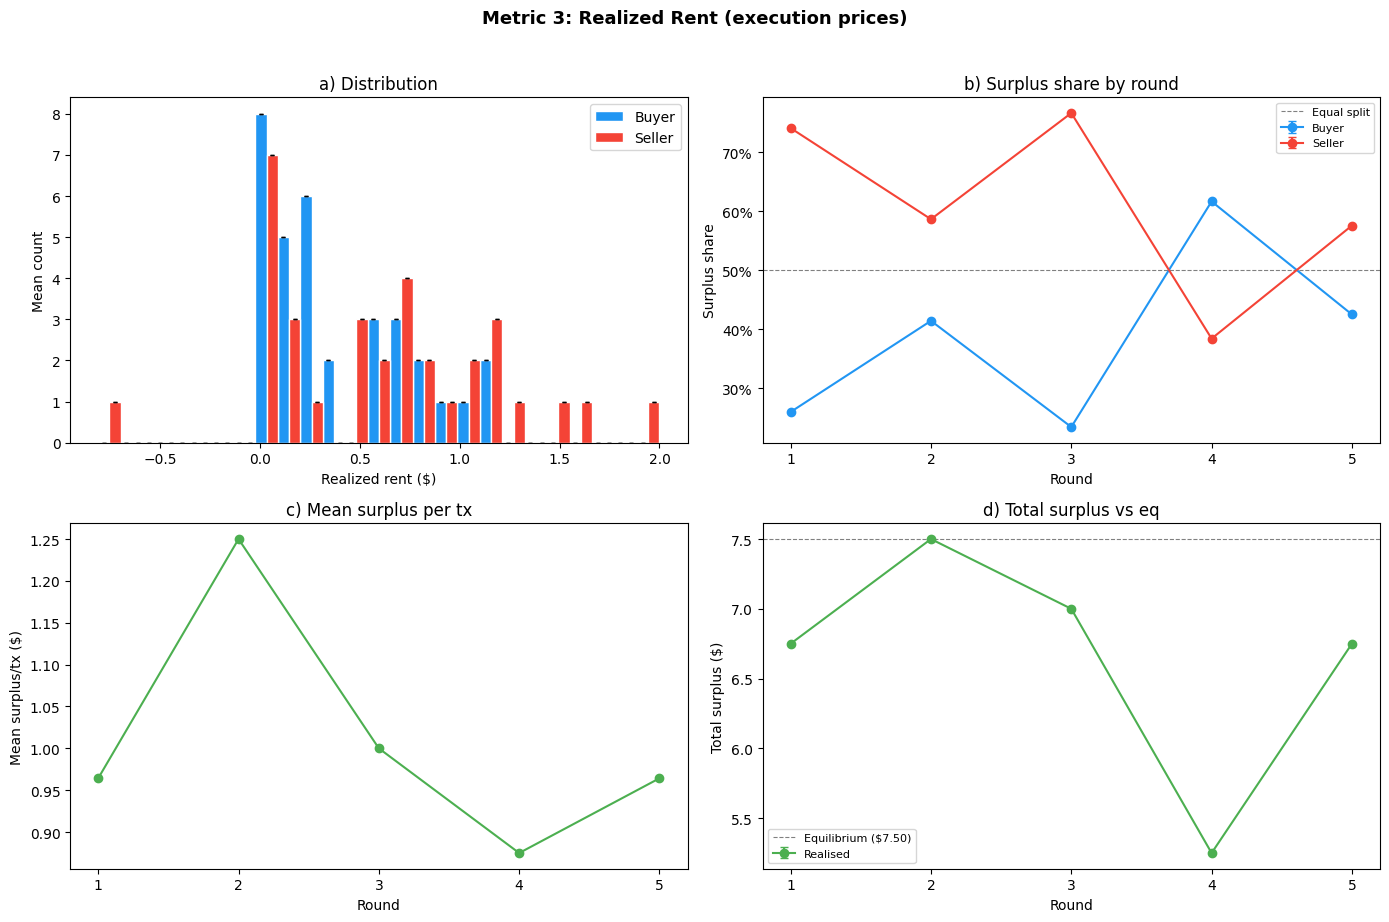

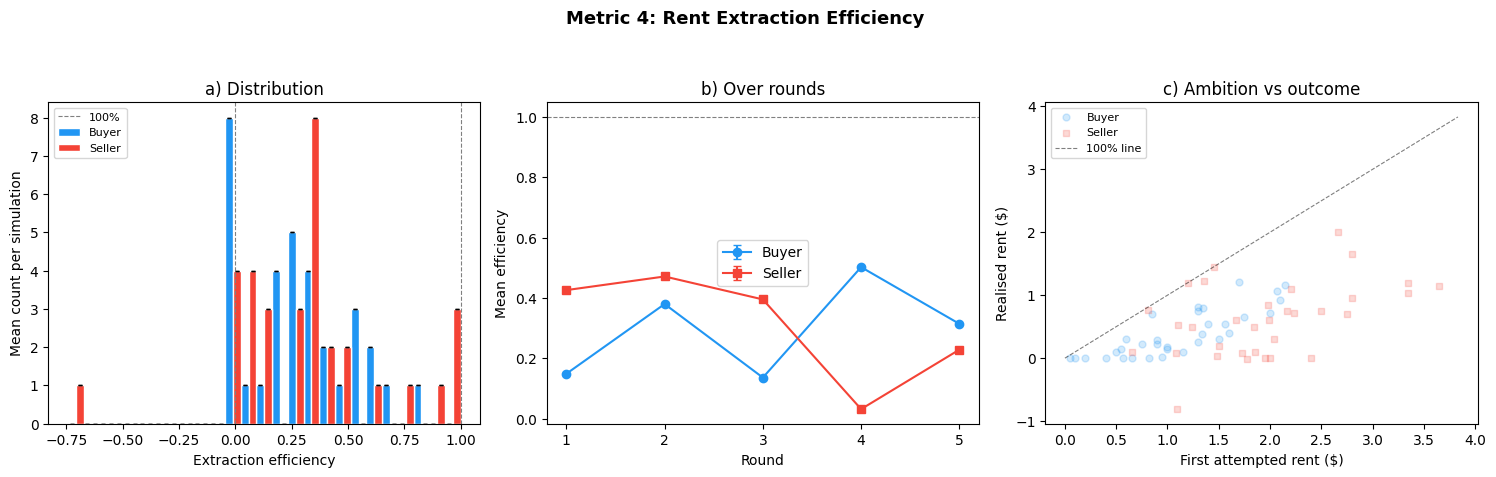

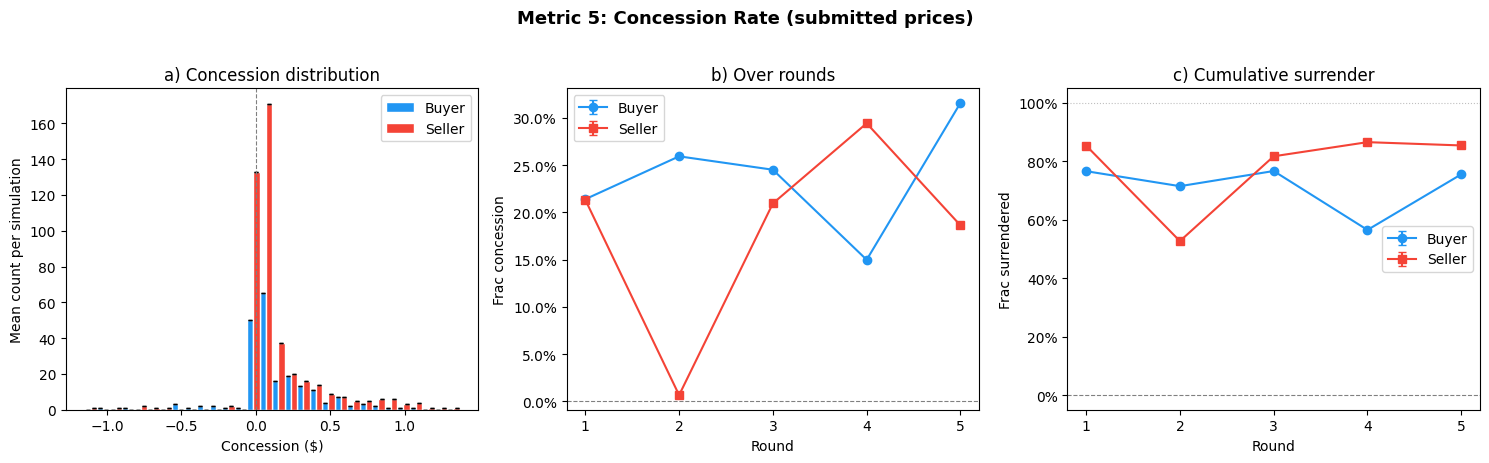

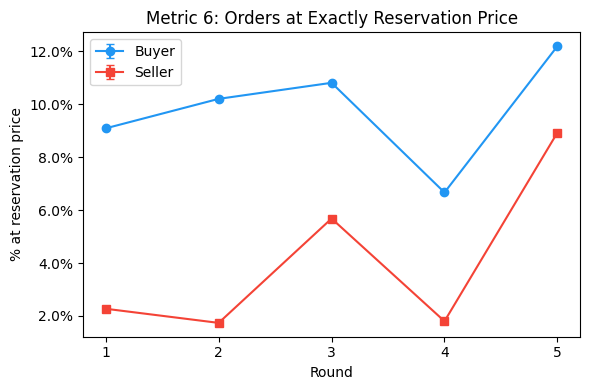

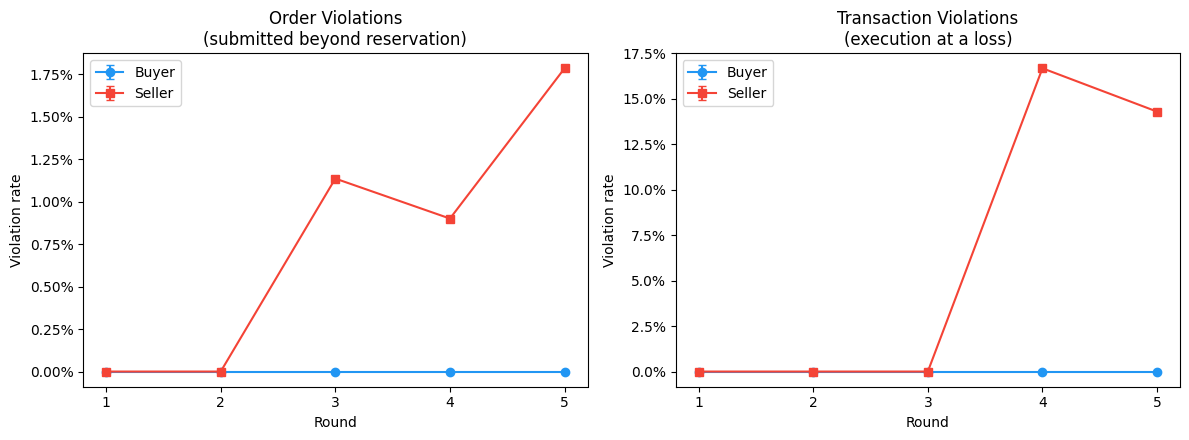

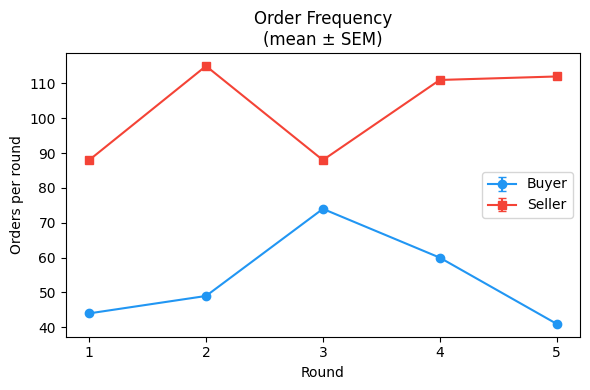

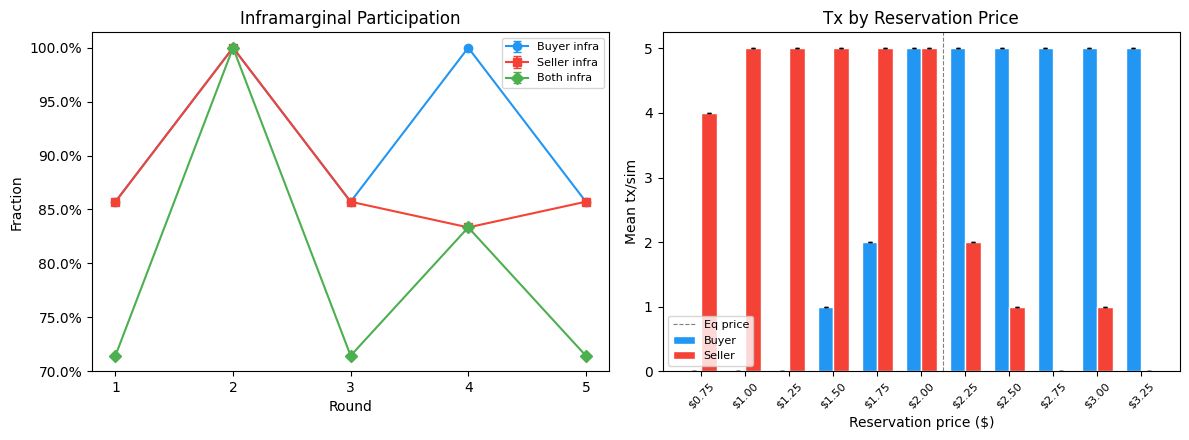

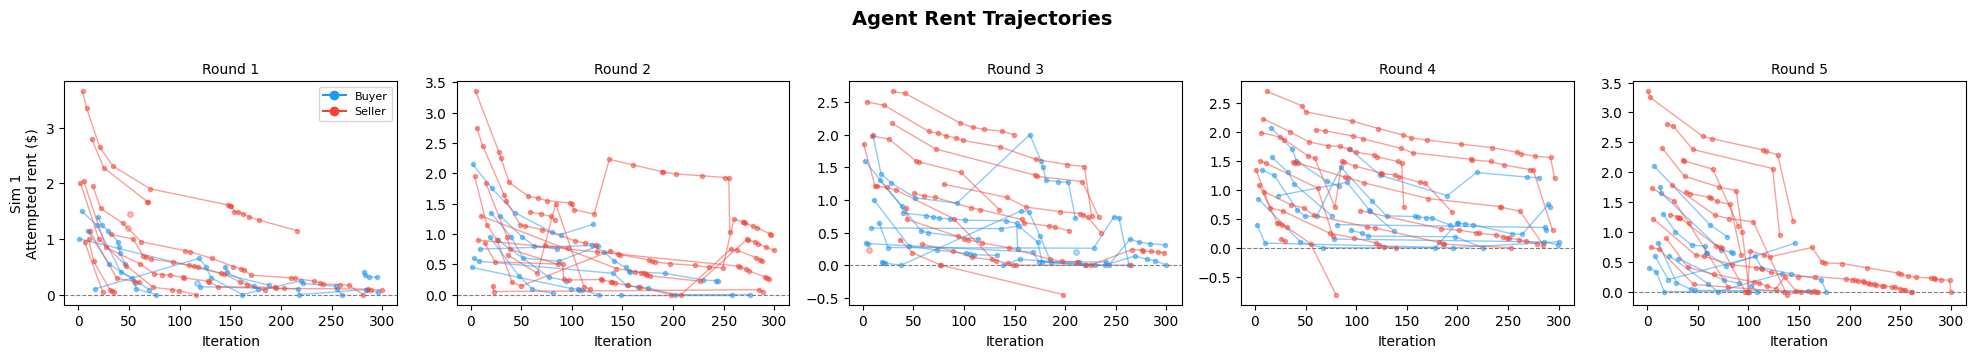

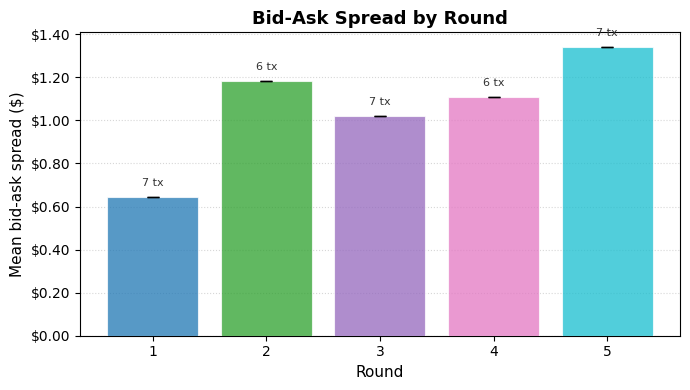

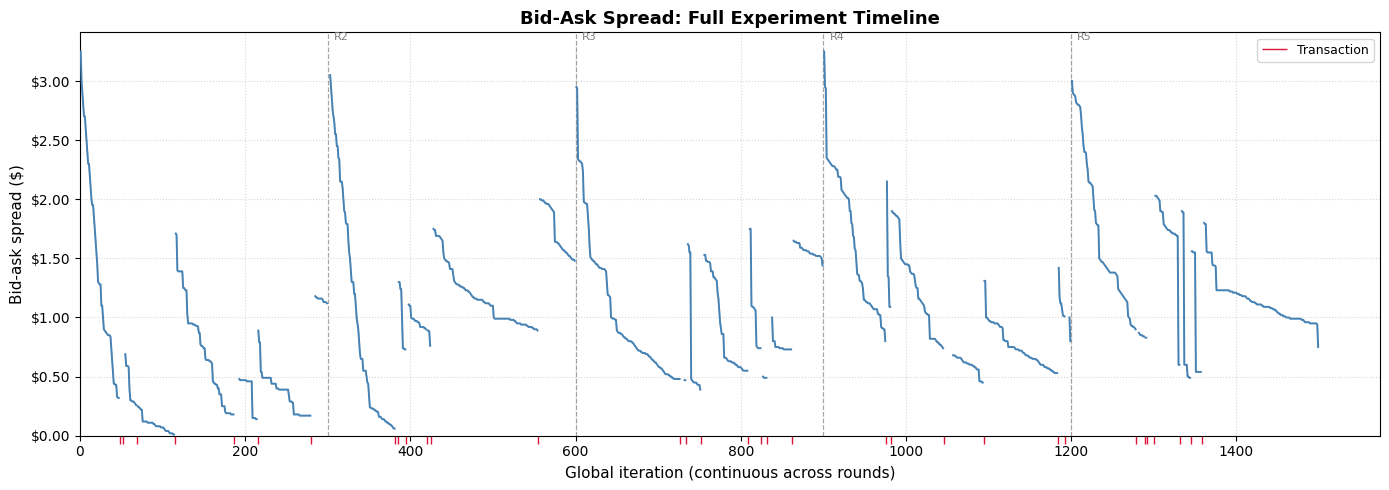

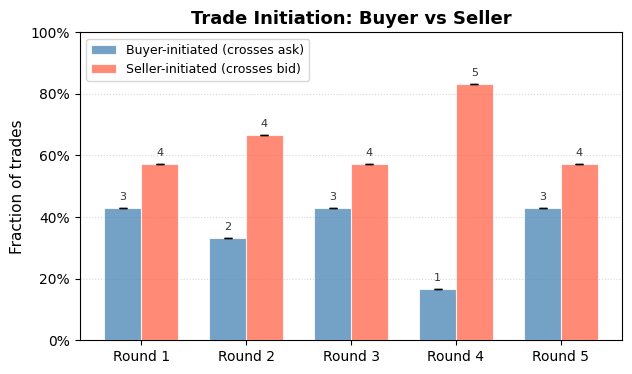

In [2]:
from results_analysis_utils import run_full_analysis

# experiment_id = "results_configs_final\smith1_gemini_large.yaml_20260502_225103"
experiment_id = "results_configs_final\smith1_gemini_small.yaml_20260502_224517"
# experiment_id = "results_configs_final\smith1_openai_large.yaml_20260502_230453"
# experiment_id = "results_configs_final\smith1_openai_small.yaml_20260502_224940"
# experiment_id = "results_configs_final\smith2_gemini_small.yaml_20260503_115428"
# experiment_id = "results_configs_final\smith2_openai_large.yaml_20260503_113239"
# experiment_id = "results_configs_final\smith2_openai_small.yaml_20260502_231606"
# experiment_id = "results_configs_final\smith4a_openai_large.yaml_20260503_121853"
# experiment_id = "results_configs_final\smith4a_openai_small.yaml_20260503_114229"

independent_rounds = False  # set to True if you are testing a ZI simulation with multiple rounds (legacy)

root_path = Path(globals()['_dh'][0]).parent
results_path = root_path / 'results' / experiment_id

# read the number of simulations from the config file
with open(results_path / 'config_used.yaml', "r") as f:
    config = yaml.safe_load(f)
n_sims = config['experiment']['n_simulations']

# Single experiment — now returns (data, metrics, figs) instead of a flat dict
data, metrics, figs = run_full_analysis(
    results_path,
    n_sims,
    config=config,
    experiment_id=experiment_id,
    independent_rounds=independent_rounds)


# Access the DataFrames for further analysis
# df_metrics = metrics.round_metrics   # per-round efficiency, alpha, etc.
# df_marsh = metrics.marshallian       # per-transaction Marshallian path data
# eq = data.eq                         # Equilibrium object (price, quantity, surplus, maps)
# rent = metrics.rent                  # dict of rent-seeking DataFrames
# figs['attempted_rent']               # individual figures by name (no 'fig_' prefix)